# Six degrees of freedom, tracked across a scan

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrmotion/blob/main/examples/02-tracking.ipynb)

Each plane sees only the motion that lies in it, and planes that between
them span the volume see all six degrees of freedom. This solves the pose from
three of them, carries it across a scan with an extended Kalman filter, and
measures what one navigator costs end to end -- which is the number a
prospective correction has to live inside.


This notebook goes the whole way: k-space samples along a radial navigator
trajectory, gridded into planes, registered against the first navigator of the
scan, solved for a pose, and carried across the scan by an extended Kalman
filter. The anatomy is a real brain slice from the
[ISMRM motion-correction workshop](https://github.com/lab-midas/ismrm-moco-workshop)
(MIT).

In [1]:
try:
    import mrmotion  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "mrmotion",
            "finufft",
            "scipy",
            "matplotlib",
        ],
        check=True,
    )

In [2]:
import io
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate, shift

import mrmotion as mm

WORKSHOP = (
    "https://raw.githubusercontent.com/lab-midas/"
    "ismrm-moco-workshop/master/data/brain_slice.npz"
)
with urllib.request.urlopen(WORKSHOP) as response:
    series = np.load(io.BytesIO(response.read()))["arr_0"]

brain = np.abs(series[20:236, :, 0])  # one frame, cropped square
brain /= brain.max()
print("anatomy", brain.shape)

anatomy (216, 216)


## What the navigator acquires, and what its trajectory extent means

A navigator's trajectory is given in cycles per field of view, running over
$[-\tfrac{1}{2}, \tfrac{1}{2}]$ across the grid it is reconstructed onto. So
the extent of the trajectory in the *scanner's* k-space is what sets the
navigator's resolution: sampling out to a fraction $g/N$ of the imaging
Nyquist and gridding onto a $g \times g$ matrix gives a plane at the full
field of view and $N/g$ times coarser, which is what a navigator is. Sampling
out to the imaging Nyquist and gridding onto the same small matrix would give
something else entirely -- full resolution over a fraction of the field of
view, aliased.

Golden-angle spokes are used here so that any consecutive run of them covers
k-space about as evenly as any other.

/home/mcencini/mrmotion/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


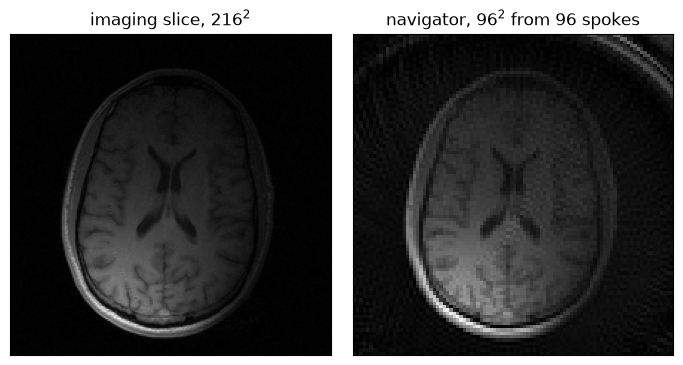

In [3]:
import finufft

GRID = 96  # navigator matrix
SPOKES = 96
N = brain.shape[0]


def radial(samples, spokes):
    """Golden-angle radial spokes, in cycles per field of view."""
    angles = np.arange(spokes) * np.pi * (3 - np.sqrt(5))
    radius = np.linspace(-0.5, 0.5, samples, endpoint=False)
    return np.stack(
        [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)],
        axis=-1,
    ).reshape(-1, 2)


def acquire(image, trajectory):
    """What the scanner measures of ``image`` along a navigator trajectory."""
    scaled = 2 * np.pi * trajectory * GRID / N  # navigator extent of image k-space
    return finufft.nufft2d2(
        np.ascontiguousarray(scaled[:, 0]),
        np.ascontiguousarray(scaled[:, 1]),
        np.ascontiguousarray(image.astype(np.complex128)),
        isign=-1,
        eps=1e-6,
        nthreads=1,
    )


trajectory = radial(GRID, SPOKES)
density = mm.estimate_density(trajectory, (GRID, GRID))

plane = mm.reconstruct_navigator(
    acquire(brain, trajectory)[None, None],  # (planes, coils, samples)
    trajectory[None],  # (planes, samples, 2)
    (GRID, GRID),
    density=density[None],
)[0]

figure, axes = plt.subplots(1, 2, figsize=(7, 3.6))
axes[0].imshow(brain, cmap="gray")
axes[0].set_title(f"imaging slice, {N}$^2$")
axes[1].imshow(plane, cmap="gray")
axes[1].set_title(f"navigator, {GRID}$^2$ from {SPOKES} spokes")
for panel in axes:
    panel.set_xticks([])
    panel.set_yticks([])
figure.tight_layout()

In [4]:
registration = mm.RigidRegistration()


def moved(image, degrees, offset):
    """Rotate about the centre, then shift, the way a head moves under a plane."""
    return shift(rotate(image, degrees, reshape=False, order=3), offset, order=3)


COILS = 8
rows, columns = np.mgrid[0:N, 0:N] / N
sensitivities = np.stack(
    [
        np.exp(
            -(
                (columns - 0.5 - 0.6 * np.cos(angle)) ** 2
                + (rows - 0.5 - 0.6 * np.sin(angle)) ** 2
            )
            / 0.35
        )
        for angle in np.linspace(0, 2 * np.pi, COILS, endpoint=False)
    ]
)
array = np.stack(
    [acquire(sensitivity * brain, trajectory) for sensitivity in sensitivities]
)
combined = mm.reconstruct_navigator(
    array[None], trajectory[None], (GRID, GRID), density=density[None]
)[0]
shifted = np.stack(
    [
        acquire(sensitivity * moved(brain, 0.0, (12.0, 12.0)), trajectory)
        for sensitivity in sensitivities
    ]
)
elsewhere = mm.reconstruct_navigator(
    shifted[None], trajectory[None], (GRID, GRID), density=density[None]
)[0]
print("a navigator of", COILS, "coils:", combined.shape)

a navigator of 8 coils: (96, 96)


## Six degrees of freedom out of three planes

Each plane is registered on its own and reports three numbers: an in-plane
rotation and two in-plane translations. Nine numbers from three planes
overdetermine the six of a rigid pose, and they are solved together rather
than assigned one plane at a time, because no single plane owns any component
of the motion.

The pose is solved as a rotation vector and only then turned into Euler
angles, which is exact. The approximation is upstream, in the plane
measurements themselves: a plane sees only the motion that lies in it.

In [5]:
AXES = [  # (row axis, column axis) of each plane
    ((1, 0, 0), (0, 1, 0)),  # axial
    ((0, 1, 0), (0, 0, 1)),  # sagittal
    ((1, 0, 0), (0, 0, 1)),  # coronal
]
SPACING = 2.0  # mm per navigator pixel
anatomy = brain[::2, ::2]  # a navigator-sized plane


def navigator(rotvec, translation):
    """The three planes a head at this pose presents to the navigator."""
    planes = []
    for row, column in AXES:
        row, column = np.array(row, float), np.array(column, float)
        normal = np.cross(row, column)
        planes.append(
            moved(
                anatomy,
                np.degrees(np.dot(rotvec, normal)),
                (
                    np.dot(translation, row) / SPACING,
                    np.dot(translation, column) / SPACING,
                ),
            )
        )
    return planes


rotvec = np.array([0.02, -0.03, 0.05])  # rad
translation = np.array([3.0, -2.0, 4.0])  # mm

tracker = mm.NavigatorMotionTracker(measurement_noise=1e-3)
tracker.track(navigator(np.zeros(3), np.zeros(3)), AXES, spacing=SPACING)
pose = tracker.track(navigator(rotvec, translation), AXES, spacing=SPACING)

print("angles      ", np.round(pose.angles, 4), " truth", rotvec)
print("translation ", np.round(pose.translation, 3), " truth", translation)

angles       [ 0.0207 -0.0311  0.0505]  truth [ 0.02 -0.03  0.05]
translation  [ 2.961 -2.011  4.047]  truth [ 3. -2.  4.]


Nothing here requires three planes, or requires them orthogonal. What it
requires is that the normals span the rotations and the in-plane axes span the
translations, and a navigator that does not is refused rather than answered
with a pose that is partly arbitrary.

In [6]:
short = mm.NavigatorMotionTracker()
short.track(navigator(np.zeros(3), np.zeros(3))[:2], AXES[:2], spacing=SPACING)
try:
    short.track(navigator(rotvec, translation)[:2], AXES[:2], spacing=SPACING)
except ValueError as error:
    print(error)

the navigator's planes do not span the rotation: they leave at least one of its three components unmeasured


## Carrying the pose across a scan

Navigators arrive through the scan, each one a noisy measurement of where the
head is now. The filter propagates a constant-velocity pose between them and
corrects it with each measurement, which also gives the sequence a pose to use
*between* navigators, from `filter.predict(dt)`.

How much the correction helps is set by `process_noise`, the filter's statement
of how far the head can move between navigators. Set it well below the real
motion and the filter trusts its own extrapolation, lags the head, and does
worse than the measurements it was given; set it high and the filter reduces to
those measurements. Neither end is the answer, and the middle is worth sweeping
against a motion trace of your own.

In [7]:
DT = 0.5
NAVIGATORS = 20
truth = np.array(
    [np.array([2.0, -1.5, 3.0]) * np.sin(step / 5) for step in range(1, NAVIGATORS + 1)]
)


def run(process_noise):
    """Track the trace, with 0.4 mm of noise on every navigator."""
    rng = np.random.default_rng(0)
    tracker = mm.NavigatorMotionTracker(process_noise=process_noise)
    tracker.track(navigator(np.zeros(3), np.zeros(3)), AXES, spacing=SPACING)
    return np.asarray(
        [
            tracker.track(
                navigator(np.zeros(3), position + rng.normal(0, 0.4, 3)),
                AXES,
                dt=DT,
                spacing=SPACING,
            ).translation
            for position in truth
        ]
    )


traces = {noise: run(noise) for noise in (1e-4, 1e-2, 1e-1, 1e2)}
for noise, trace in traces.items():
    rms = np.sqrt(((trace - truth) ** 2).mean())
    note = "the measurements themselves" if noise >= 1e2 else ""
    print(f"process_noise {noise:<8g} rms {rms:.3f} mm   {note}")

process_noise 0.0001   rms 0.802 mm   
process_noise 0.01     rms 0.335 mm   
process_noise 0.1      rms 0.318 mm   
process_noise 100      rms 0.368 mm   the measurements themselves


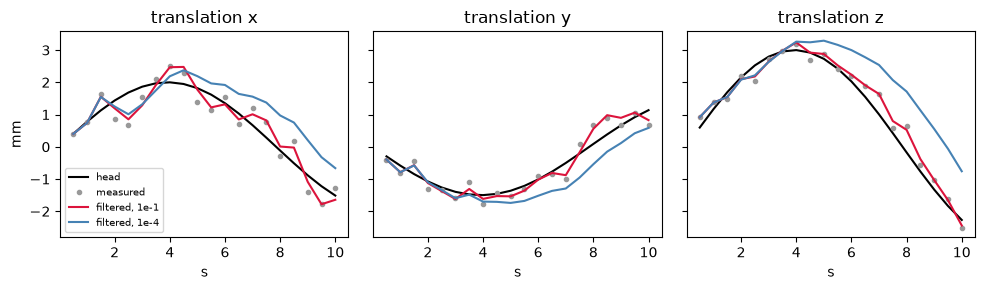

In [8]:
seconds = DT * np.arange(1, NAVIGATORS + 1)

figure, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for axis, panel, name in zip(range(3), axes, "xyz", strict=True):
    panel.plot(seconds, truth[:, axis], "k-", label="head")
    panel.plot(seconds, traces[1e2][:, axis], ".", color="0.6", label="measured")
    panel.plot(
        seconds, traces[1e-1][:, axis], "-", color="crimson", label="filtered, 1e-1"
    )
    panel.plot(
        seconds, traces[1e-4][:, axis], "-", color="steelblue", label="filtered, 1e-4"
    )
    panel.set_title(f"translation {name}")
    panel.set_xlabel("s")
axes[0].set_ylabel("mm")
axes[0].legend(fontsize=7)
figure.tight_layout()

## One thread, and checked rather than assumed

Prospective correction shares a machine with the reconstruction it steers, and
owes it a pose before the next acquisition. A step that usually takes 20 ms and
occasionally 200, because several libraries each took every core, is worse than
one that always takes 40. Four libraries take thread counts and each is told
separately; `thread_counts` reads them back, so what is set can be asserted
from inside the block rather than hoped for.

FINUFFT is not among them, because it has no global to set: its count travels
with the call, which is why `reconstruct_navigator` takes `threads`.

In [9]:
with mm.single_threaded():
    print(mm.thread_counts())
print("outside:", mm.thread_counts())

{'torch': 1, 'simpleitk': 1, 'blas': 1}
outside: {'torch': 10, 'simpleitk': 20, 'blas': 20}


## What a navigator costs

Prospective correction owes the sequence a pose before the next acquisition, so
the number that matters is the latency of one navigator end to end: grid its
planes, register each against the reference, solve the pose, filter it.

Gridding is not where the time goes. It runs at a few million samples a second
on one core and scales with the samples, so the coil count multiplies it while
the matrix size barely moves it. Registration costs several times more than the
gridding of the same plane, and it is what sets the budget.

In [10]:
import time


def milliseconds(call, repeats=5):
    call()
    start = time.perf_counter()
    for _ in range(repeats):
        call()
    return 1e3 * (time.perf_counter() - start) / repeats


with mm.single_threaded():
    once = milliseconds(
        lambda: mm.estimate_density(trajectory, (GRID, GRID)), repeats=1
    )
    grid_ms = milliseconds(
        lambda: mm.reconstruct_navigator(
            array[None], trajectory[None], (GRID, GRID), density=density[None]
        )
    )
    register_ms = milliseconds(
        lambda: registration(combined, elsewhere, spacing=(1.0, 1.0)), repeats=3
    )

    # A trace, not one pose timed over and over: a filter handed the same
    # measurement twice predicts motion that is not there, and the next
    # registration starts from a worse guess than it ever would in a scan.
    stack = np.stack([trajectory] * 3)
    weights = np.stack([density] * 3)
    trace = [
        np.stack(
            [
                np.stack(
                    [
                        acquire(
                            sensitivity * moved(brain, 0.0, (offset, 0.0)), trajectory
                        )
                        for sensitivity in sensitivities
                    ]
                )
            ]
            * 3
        )
        for offset in 3.0 * np.sin(np.arange(6) / 2)
    ]
    clock = mm.NavigatorMotionTracker()
    start = time.perf_counter()
    for measurement in trace:
        clock.track(
            list(
                mm.reconstruct_navigator(
                    measurement, stack, (GRID, GRID), density=weights
                )
            ),
            AXES,
            dt=DT,
            spacing=SPACING,
        )
    navigator_ms = 1e3 * (time.perf_counter() - start) / len(trace)

samples = array.size
print(f"density, once at start-up      {once:7.0f} ms")
print(
    f"grid one plane, {COILS} coils      {grid_ms:7.2f} ms"
    f"  ({samples / grid_ms / 1e3:.1f} Msample/s)"
)
print(f"register one plane             {register_ms:7.1f} ms")
print(f"a whole navigator, 3 planes    {navigator_ms:7.1f} ms")

density, once at start-up          223 ms
grid one plane, 8 coils        10.89 ms  (6.8 Msample/s)
register one plane                47.7 ms
a whole navigator, 3 planes      133.7 ms


## Where to go from here

- `mm.RigidRegistration` is the plane measurement on its own, and takes the
  SimpleITK knobs -- metric, sampling, shrink factors -- if the default schedule
  is not right for your navigator.
- `mm.RigidMotionEKF` is the filter on its own, and takes any object that
  registers two images, so a navigator that is not made of planes can still use
  it.
- `mm.reconstruct_navigator` takes multiple coils and combines them by root sum
  of squares, which needs no sensitivities: the planes are registered against
  each other, not diagnosed.